Tatiana Gallo.  
Juan David Loaiza Agudelo

1. Exploración y descripción de la base de datos

In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
# Cargar el archivo
df = pd.read_excel('Diagnostics.xlsx')


df.head()

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354


In [8]:

total_registros = len(df)

total_sujetos = df['FileName'].nunique()

print(f"Número total de registros: {total_registros}")
print(f"Número total de sujetos únicos: {total_sujetos}")

Número total de registros: 10646
Número total de sujetos únicos: 10646


In [9]:
# tipos de arritmias

tipos_arritmias = df['Rhythm'].unique()
print(f"Tipos de arritmias disponibles:\n {tipos_arritmias}")

Tipos de arritmias disponibles:
 ['AFIB' 'SB' 'SA' 'AF' 'SR' 'ST' 'SVT' 'AT' 'AVNRT' 'SAAWR' 'AVRT']


Tabla de Distribución


,Tipo de Arritmia,Número de Registros
0,SB,3889
1,SR,1826
2,AFIB,1780
3,ST,1568
4,SVT,587
5,AF,445
6,SA,399
7,AT,121
8,AVNRT,16
9,AVRT,8


/tmp/ipykernel_4476/2013982611.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo_arritmias, x='Tipo de Arritmia', y='Número de Registros', palette='viridis')


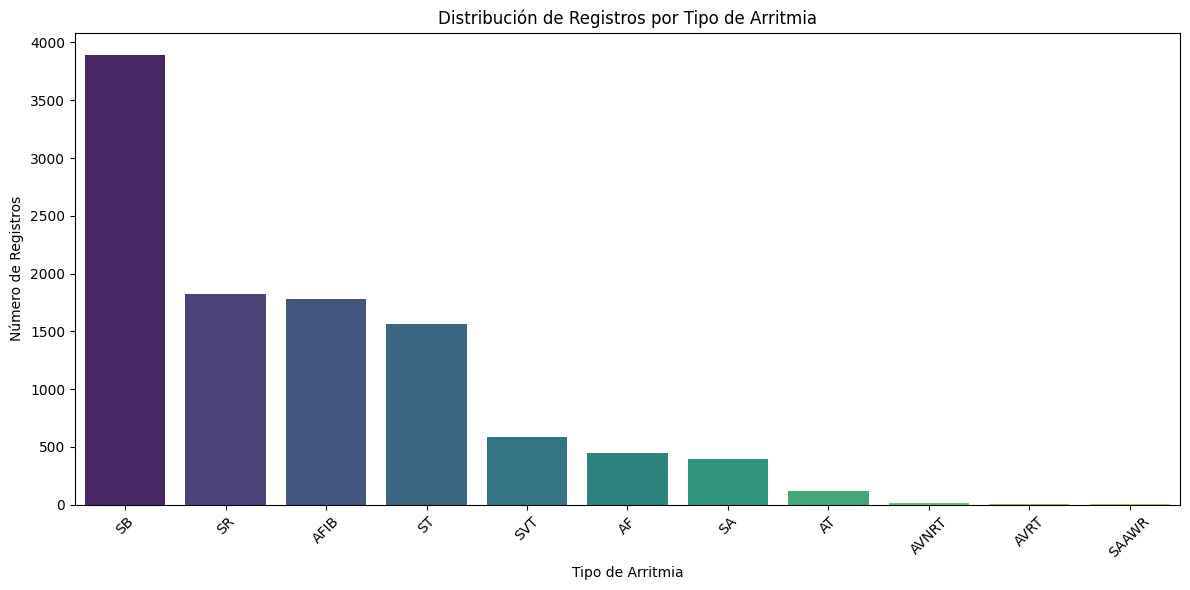

In [10]:
conteo_arritmias = df['Rhythm'].value_counts().reset_index()
conteo_arritmias.columns = ['Tipo de Arritmia', 'Número de Registros']

print("Tabla de Distribución")
display(conteo_arritmias)

plt.figure(figsize=(12, 6))
sns.barplot(data=conteo_arritmias, x='Tipo de Arritmia', y='Número de Registros', palette='viridis')
plt.title('Distribución de Registros por Tipo de Arritmia')
plt.xlabel('Tipo de Arritmia')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
nombre_archivo = 'MUSE_20180114_075026_69000.csv'
senal_ejemplo = pd.read_csv(nombre_archivo)


num_canales = senal_ejemplo.shape[1]
nombres_canales = senal_ejemplo.columns.tolist()


print(f"Número de canales disponibles: {num_canales}")
print(f"Derivaciones: {nombres_canales}\n")

fs = 500
num_muestras = len(senal_ejemplo)
duracion_segundos = num_muestras / fs

print(f"Frecuencia de muestreo (Fs): {fs} Hz")
print(f"Total de muestras registradas en el archivo: {num_muestras}")
print(f"Duración total del registro: {duracion_segundos} segundos")

Número de canales disponibles: 12
Derivaciones: ['-3.2286', '-26.846', '-15.383', '17.205', '9.1288', '-25.155', '-43.954', '-72.78', '-76.289', '-41.65', '-50.223', '7.7015']

Frecuencia de muestreo (Fs): 500 Hz
Total de muestras registradas en el archivo: 4999
Duración total del registro: 9.998 segundos


**Visualización y caracterización de las señales**

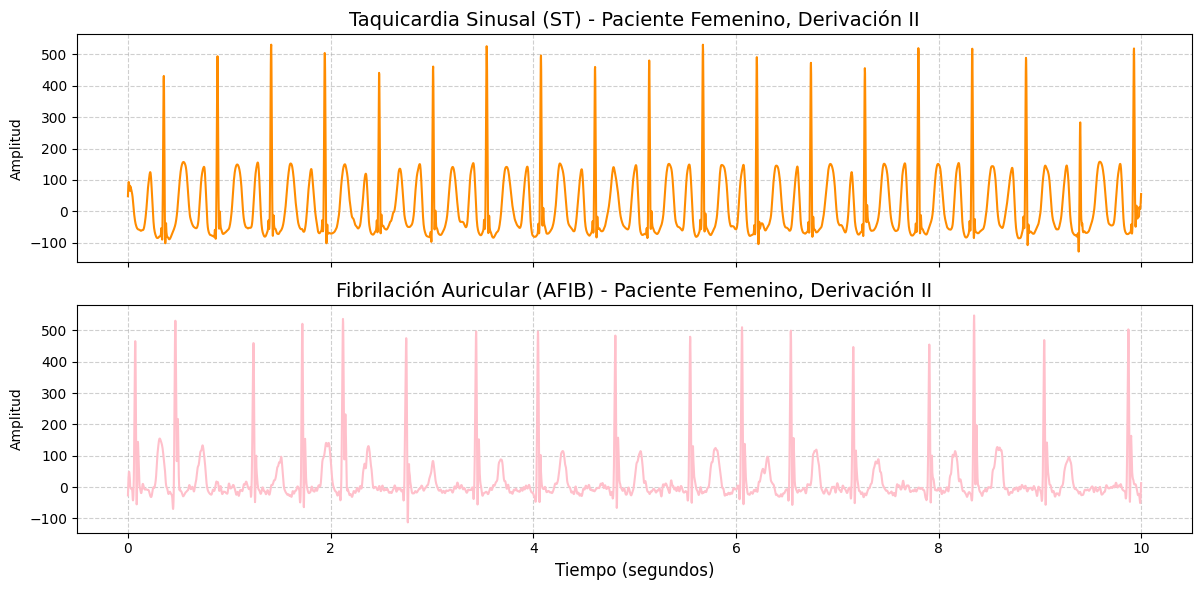

In [12]:

file_afib = 'MUSE_20180114_075026_69000.csv'
file_st = 'MUSE_20180113_131104_16000.csv'

LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

df_afib = pd.read_csv(file_afib, header=None, names=LEADS)
df_st = pd.read_csv(file_st, header=None, names=LEADS)

# Crear el vector de tiempo
fs = 500
tiempo = np.arange(len(df_afib)) / fs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Graficar Taquicardia Sinusal
ax1.plot(tiempo, df_st['II'], color='darkorange')
ax1.set_title('Taquicardia Sinusal (ST) - Paciente Femenino, Derivación II', fontsize=14)
ax1.set_ylabel('Amplitud')
ax1.grid(True, linestyle='--', alpha=0.6)

# Graficar Fibrilación Auricular
ax2.plot(tiempo, df_afib['II'], color='pink')
ax2.set_title('Fibrilación Auricular (AFIB) - Paciente Femenino, Derivación II', fontsize=14)
ax2.set_xlabel('Tiempo (segundos)', fontsize=12)
ax2.set_ylabel('Amplitud')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Morfología**: En la señal de Taquicardia Sinusal (ST), el ciclo cardíaco resulta muy repetitivo y predecible; a pesar de la ondulación en la línea de base, cada latido tiene exactamente la misma arquitectura que el anterior. En cambio, la señal de Fibrilación Auricular (AFIB) no tiene un patrón estable entre latidos, mostrando oscilacionescaóticas que evidencian la ausencia de ondas fisiológicas organizadas.[1]

**Amplitud**: Ambas señales muestran una magnitud de energía equivalente. Los picos máximos de los complejos QRS en la paciente con ST alcanzan valores estables alrededor de las 500 unidades, al igual que los picos de la paciente con AFIB (entre 450 y 500 unidades)[3]. Esto demuestra que la fuerza eléctrica de despolarización ventricular se mantiene conservada en ambas condiciones.[1]

**Frecuencia Cardíaca**: Al contabilizar los latidos en la ventana de 10 segundos, la señal ST presenta 19 complejos QRS, que es una frecuencia cardíaca de $114\text{ bpm}$ (confirmando el criterio clínico de taquicardia al superar los $100\text{ bpm}$)[1]. Por su parte, la señal AFIB registra 18 complejos, equivalentes a $108\text{ bpm}$, indicando una respuesta ventricular que también es acelerada.

**Regularidad de los Latidos**: Representa la diferencia diagnóstica y matemática entre ambas patologías. En la ST, el intervalo de tiempo R-R entre cada pico es constante y exacto a lo largo de los 10 segundos. En la AFIB, la distancia horizontal entre picos es totalmente errática, alternando latidos muy agrupados con pausas prolongadas, lo cual constituye el sello electrocardiográfico característico ("irregularmente irregular") de esta arritmia.[1]

**Análisis estadístico entre arritmias**


,Taquicardia Sinusal (ST),Fibrilación Auricular (AFIB)
Media,13.607421,21.241662
Desviación Estándar,99.681775,77.959456
Máximo,530.970000,547.990000
Mínimo,-128.310000,-112.970000
Frecuencia Cardíaca (lpm),114.000000,102.000000
RMS,100.606253,80.801516


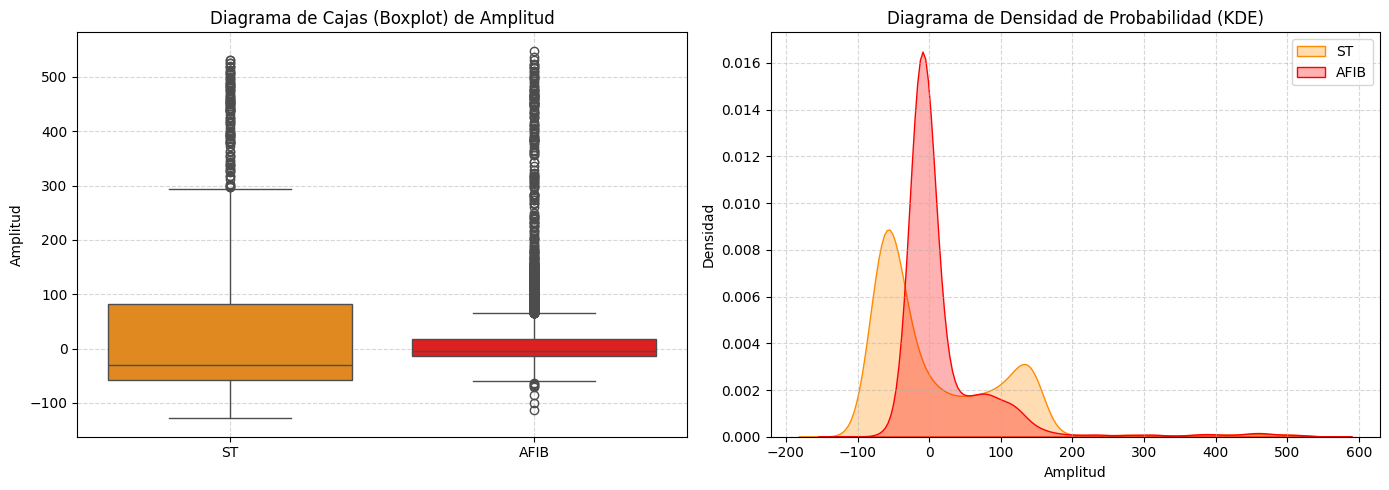

In [13]:
# Extraer los arreglos numéricos de la derivación II
sig_st = df_st['II'].values
sig_afib = df_afib['II'].values
fs = 500

# Detección de picos R para calcular la Frecuencia Cardíaca
peaks_st, _ = find_peaks(sig_st, height=200, distance=int(fs * 0.3))
peaks_afib, _ = find_peaks(sig_afib, height=200, distance=int(fs * 0.3))

fc_st = len(peaks_st) * 6
fc_afib = len(peaks_afib) * 6

# Función para calcular los parámetros descriptivos
def obtener_estadisticas(senal, fc):
    return {
        'Media': np.mean(senal),
        'Desviación Estándar': np.std(senal),
        'Máximo': np.max(senal),
        'Mínimo': np.min(senal),
        'Frecuencia Cardíaca (lpm)': fc,
        'RMS': np.sqrt(np.mean(senal**2))
    }


res_st = obtener_estadisticas(sig_st, fc_st)
res_afib = obtener_estadisticas(sig_afib, fc_afib)

tabla_comparativa = pd.DataFrame([res_st, res_afib], index=['Taquicardia Sinusal (ST)', 'Fibrilación Auricular (AFIB)']).T
display(tabla_comparativa)

#GRÁFICOS DESCRIPTIVOS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot
df_box = pd.DataFrame({'ST': sig_st, 'AFIB': sig_afib})
sns.boxplot(data=df_box, ax=axes[0], palette=['darkorange', 'red'])
axes[0].set_title('Diagrama de Cajas (Boxplot) de Amplitud')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Diagrama de Densidad
sns.kdeplot(sig_st, ax=axes[1], color='darkorange', label='ST', fill=True, alpha=0.3)
sns.kdeplot(sig_afib, ax=axes[1], color='red', label='AFIB', fill=True, alpha=0.3)
axes[1].set_title('Diagrama de Densidad de Probabilidad (KDE)')
axes[1].set_xlabel('Amplitud')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Fibrilación Auricular (AFIB)

* **Fisiología y forma de la onda:** En la AFIB, las aurículas no laten de forma coordinada, sino que tiemblan. Por esto, la onda P normal desaparece y es reemplazada por pequeñas oscilaciones o temblores (ondas f). [1]
* **Comportamiento en las gráficas (KDE y Boxplot):** Como hay esa falta de contracción fuerte en las aurículas, la señal pasa gran parte del tiempo casi en reposo eléctrico (cerca de los 0 mV). Esto hace que en el diagrama KDE veamos un pico muy alto y agudo centrado exactamente en el cero. En el Boxplot, esto se nota porque la caja central es muy delgada, mostrando que la mayoría de los datos no varían mucho. [2,4]
* **Los picos R y el ritmo irregular:** Para protegerse de este caos, el corazón solo deja pasar algunos impulsos hacia los ventrículos de forma desordenada. Esos latidos fuertes son los puntos sueltos (outliers) que vemos por encima de la caja en el Boxplot, los cuales rompen el silencio eléctrico de manera repentina y sin un ritmo constante.

**Taquicardia Sinusal (ST)

* **Fisiología:** Aquí la ruta eléctrica del corazón funciona correctamente, solo que va más rápido de lo normal (más de 100 latidos por minuto). Todas las partes del latido (las ondas P, el complejo QRS y la onda T) están completas y conservan su forma.[1]
* **comportamiento en la gráfica KDE:** Como hay ondas completas formándose todo el tiempo, la señal no se queda estancada en el cero. Por eso la gráfica KDE adopta una forma con dos montañas (bimodal), indicando que el voltaje sube y baja constantemente siguiendo el ciclo normal del corazón.[1,2]
* **Métricas de energía (RMS y Desviación Estándar):** Al tener un ciclo constante con ondas gruesas, la señal maneja más energía global. Esto explica matemáticamente por qué el valor RMS (100.61) y la desviación estándar (99.68) son mayores que en la AFIB (RMS 80.80 y STD 77.96). La caja más ancha en el Boxplot de la ST confirma esta mayor variación constante de voltajes.

**Amplitud Máxima**

* Aunque son arritmias muy distintas, los valores máximos alcanzados por los picos son casi idénticos (ST=530.97 y AFIB=547.99). Fisiológicamente, esto tiene mucho sentido porque la AFIB es un problema de las aurículas (las cámaras superiores). Una vez que el impulso eléctrico logra pasar hacia abajo, los ventrículos se contraen con la misma fuerza y masa muscular que lo harían en un corazón sano y rápido como el de la ST.[3,4]

Los datos calculados comprueban que la Taquicardia Sinusal es un ritmo rápido, ordenado y con variaciones de voltaje constantes; mientras que la Fibrilación Auricular es un ritmo desorganizado donde la señal pasa mucho tiempo en voltajes muy bajos, dependiendo de latidos ventriculares irregulares para mantener el funcionamiento del corazón.[1,4]

**INTERPRETACION DE RESULTADOS**

In [14]:

from scipy.stats import levene, mannwhitneyu, shapiro, ttest_ind

# 1. Selección de la derivación a comparar
lead = 'II'

grupo_st = df_st[lead].dropna()
grupo_afib = df_afib[lead].dropna()

# 2. Comprobación de Normalidad (Shapiro-Wilk con submuestra N=500)
sample_st = grupo_st.sample(500, random_state=42) if len(grupo_st) > 500 else grupo_st
sample_afib = grupo_afib.sample(500, random_state=42) if len(grupo_afib) > 500 else grupo_afib

stat_norm_st, p_norm_st = shapiro(sample_st)
stat_norm_afib, p_norm_afib = shapiro(sample_afib)

# 3. Comprobación de Homocedasticidad (Levene)
stat_lev, p_lev = levene(grupo_st, grupo_afib)

alpha = 0.05

print(f" 1. VERIFICACIÓN DE SUPUESTOS (Derivación {lead})")

print(f"Normalidad ST   -> W = {stat_norm_st:.4f}, p-valor = {p_norm_st:.5e}")
print(f"Normalidad AFIB -> W = {stat_norm_afib:.4f}, p-valor = {p_norm_afib:.5e}")
print(f"Homocedasticidad (Levene) -> W = {stat_lev:.4f}, p-valor = {p_lev:.5e}")

# 4. Selección y ejecución de la prueba
if p_norm_st > alpha and p_norm_afib > alpha and p_lev > alpha:
    prueba_usada = "Prueba t de Student para muestras independientes"
    stat_test, p_val = ttest_ind(grupo_st, grupo_afib, equal_var=True)
elif p_norm_st > alpha and p_norm_afib > alpha and p_lev <= alpha:
    prueba_usada = "Prueba t de Welch (varianzas desiguales)"
    stat_test, p_val = ttest_ind(grupo_st, grupo_afib, equal_var=False)
else:
    prueba_usada = "Prueba U de Mann-Whitney (No Paramétrica)"
    stat_test, p_val = mannwhitneyu(grupo_st, grupo_afib, alternative="two-sided")


print(" 2. DECISIÓN Y PRUEBA EJECUTADA")
print(f"Prueba seleccionada  : {prueba_usada}")
print(f"Estadístico de prueba: {stat_test:,.4f}")
print(f"p-valor              : {p_val:.5e}")

if p_val < alpha:
    print("Decisión             : Se RECHAZA la hipótesis nula (H0).")
    print("Conclusión           : Existen diferencias estadísticamente significativas.")
else:
    print("Decisión             : NO se rechaza la hipótesis nula (H0).")

 1. VERIFICACIÓN DE SUPUESTOS (Derivación II)
Normalidad ST   -> W = 0.8078, p-valor = 6.08742e-24
Normalidad AFIB -> W = 0.6174, p-valor = 8.35956e-32
Homocedasticidad (Levene) -> W = 510.4535, p-valor = 2.82605e-110
 2. DECISIÓN Y PRUEBA EJECUTADA
Prueba seleccionada  : Prueba U de Mann-Whitney (No Paramétrica)
Estadístico de prueba: 9,470,739.5000
p-valor              : 8.75351e-98
Decisión             : Se RECHAZA la hipótesis nula (H0).
Conclusión           : Existen diferencias estadísticamente significativas.


**Prueba utilizada**: Prueba U de Mann-Whitney (No Paramétrica). Se seleccionó tras confirmar que los datos violaron el supuesto de normalidad en la prueba de Shapiro-Wilk ($p = 6.09 \times 10^{-24}$ para ST y $p = 8.36 \times 10^{-32}$ para AFIB) y el supuesto de homocedasticidad en la prueba de Levene ($p = 2.83 \times 10^{-110}$), utilizando los registros analizados del dataset.


**Hipótesis nula ($H_0$)**: No existe una diferencia estadísticamente significativa en la distribución de voltaje/amplitud de la señal ECG en la derivación II entre la Taquicardia Sinusal (ST) y la Fibrilación Auricular (AFIB).

**Hipótesis alternativa ($H_1$)**: Existe una diferencia estadísticamente significativa en la distribución de voltaje/amplitud de la señal ECG en la derivación II entre la Taquicardia Sinusal (ST) y la Fibrilación Auricular (AFIB).

**Nivel de significancia ($\alpha$)**: $0.05$ (95% de confianza).

**Estadístico de prueba ($U$)**: 9,470,739.50.


**p-valor**: $8.75 \times 10^{-98}$ ($p < 0.001$) .

**Decisión estadística**: Se rechaza la hipótesis nula ($H_0$) y se acepta la hipótesis alternativa ($H_1$), dado que el p-valor es significativamente menor al nivel de significancia $\alpha = 0.05$.

**Interpretación fisiológica**: La prueba confirma diferencias estadísticamente significativas con más del 99.9% de certeza. La Taquicardia Sinusal conserva una despolarización sinusal organizada con oscilaciones continuas y periódicas de alto voltaje. Por el contrario, la Fibrilación Auricular pierde la contracción auricular coordinada, lo que provoca que la señal colapse y permanezca la mayor parte del tiempo cerca de la línea isoeléctrica ($0\text{ mV}$), interrumpida solo de forma esporádica por despolarizaciones ventriculares irregulares [1, 3].

**CONCLUSIONES**

**Diferencia estadística clara**: La prueba U de Mann-Whitney confirmó con una certeza superior al $99.9\%$ ($p < 0.001$) que la Taquicardia Sinusal ($ST$) y la Fibrilación Auricular ($AFIB$) tienen distribuciones de voltaje totalmente distintas en la derivación II.

**Diferencia de energía ($RMS$)**: La Taquicardia Sinusal maneja mayor energía eficaz ($\text{RMS} = 100.61$) que la Fibrilación Auricular ($\text{RMS} = 80.80$). Esto ocurre porque la $ST$ mantiene un ciclo completo y constante (ondas P, QRS y T), mientras que en la $AFIB$ las aurículas pierden contracción y la señal pasa mucho tiempo plana cerca de cero.

**Fuerza ventricular conservada**: La altura máxima de las pulsaciones (picos QRS) fue prácticamente la misma en ambas arritmias ($\text{ST} = 530.97$, $\text{AFIB} = 547.99$). Esto demuestra que el fallo de la $AFIB$ ocurre únicamente en las aurículas; cuando el estímulo logra bajar a los ventrículos, estos se contraen con la misma fuerza que en la $ST$.

**La frecuencia cardíaca no basta para diagnosticar**: Ambas pacientes registraron el corazón acelerado ($114\text{ bpm}$ en ST y $102\text{ bpm}$ en AFIB), por lo que el ritmo por sí solo no sirve para distinguirlas. La clave del diagnóstico está en la regularidad del pulso (la $ST$ es rítmica y constante, mientras que la $AFIB$ es totalmente irregular) y en la forma de la gráfica de densidad ($\text{KDE}$).

**Justificación de la prueba utilizada**: Las pruebas preliminares (Shapiro-Wilk y Levene) mostraron que los datos no cumplían con la normalidad ni con la igualdad de varianzas ($p < 0.05$). Esto descartó el uso de la prueba $t$ de Student y justificó el uso obligatorio de la prueba no paramétrica U de Mann-Whitney.

**REFERENCIAS**

- [1]Goldberger, A. L., Amaral, L. A., Glass, L., Hausdorff, J. M., Ivanov, P. C., Mark, R. G., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: components of a new research resource for complex physiologic signals. Circulation, 101(23), e215-e220. https://doi.org/10.1161/01.cir.101.23.e215


- [2]Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., ... & SciPy 1.0 Contributors. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. Nature Methods, 17(3), 261-272. https://doi.org/10.1038/s41592-019-0686-2


- [3]Zheng, J., Zhang, J., Danioko, S., Yao, H., Guo, H., & Rakovski, C. (2020). A 12-lead electrocardiogram database for arrhythmia research covering more than 10,000 patients. Scientific Data, 7(1), 48. https://doi.org/10.1038/s41597-020-0386-x

- [4] Sheskin, D. J. (2020). Handbook of Parametric and Nonparametric Statistical Procedures (5th ed.). CRC Press.